In [33]:
#权重损失实现，减少过拟合现象
import torch
import torch.nn as nn
from d2l import torch as d2l

In [34]:
#数据集
n_train,n_test,num_inputs,batch_size=20,100,200,5
true_w,true_b=torch.ones((num_inputs,1))*0.01,0.05
train_data=d2l.synthetic_data(true_w,true_b,n_train)
train_iter=d2l.load_array(train_data,batch_size)
test_data=d2l.synthetic_data(true_w,true_b,n_test)
test_iter=d2l.load_array(test_data,batch_size,is_train=False)

In [35]:
#初始化参数
def _init_params():
    w=torch.normal(0,1,size=(num_inputs,1),requires_grad=True)
    b=torch.zeros(1,requires_grad=True)
    return [w,b]

In [36]:
#定义L2范数惩罚
def l2_penalty(w):
    return torch.sum(w.pow(2))/2

In [37]:
def train(lambd):
    w,b=_init_params()
    net,loss=lambda X:d2l.linreg(X,w,b),d2l.squared_loss
    num_epochs,lr = 300,0.003
    animator = d2l.Animator(xlabel='epochs', ylabel='loss', yscale='log',
                            xlim=[5, num_epochs], legend=['train', 'test'])
    for epoch in range(num_epochs):
        for X,y in train_iter:
            l=loss(net(X),y)+lambd * l2_penalty(w)
            l.sum().backward()
            d2l.sgd([w,b],lr,batch_size)
        if (epoch+1) % 5 == 0:
            animator.add(epoch+1,(d2l.evaluate_loss(net,train_iter,loss),
                                 (d2l.evaluate_loss(net,test_iter,loss))))
    print('w的范数是：',torch.norm(w).item())        

w的范数是： 14.103337287902832


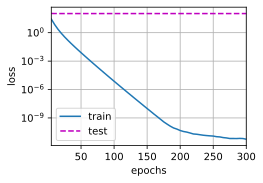

In [22]:
train(lambd=0)

w的范数是： 0.041707463562488556


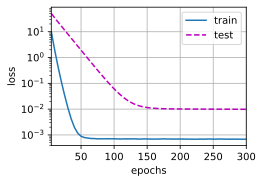

In [23]:
train(lambd=3)

w的范数是： 0.027720456942915916


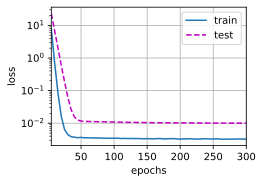

In [24]:
train(lambd=10)

In [58]:
def train_concis(lambd):
    net = nn.Sequential(nn.Linear(num_inputs,1))
    for param in net.parameters():
        param.data.normal_()
    loss = nn.MSELoss()
    num_epochs,lr=100,0.003
    trainer = torch.optim.SGD([{"params":net[0].weight,'weight_decay':lambd},{
        "params":net[0].bias}],lr=lr)
    animator = d2l.Animator(xlabel='epochs', ylabel='loss', yscale='log',
                            xlim=[5, num_epochs], legend=['train', 'test'])
    for epochs in range(num_epochs):
        for X,y in train_iter:
            with torch.enable_grad():
                trainer.zero_grad()
                l=loss(net(X),y)
            l.backward()
            trainer.step()
            if (epochs+1) % 5 == 0:
                animator.add(epochs+1,(d2l.evaluate_loss(net,train_iter,loss),
                                 (d2l.evaluate_loss(net,test_iter,loss))))
    print('权重的范数是：',torch.norm(net[0].weight).item())        

权重的范数是： 12.541131973266602


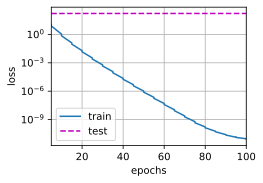

In [59]:
train_concis(0)

权重的范数是： 0.033021118491888046


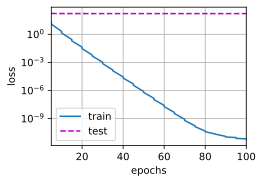

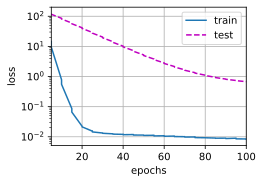

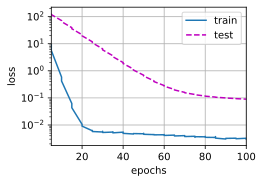

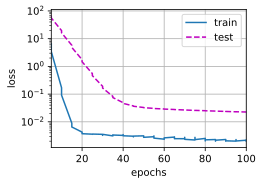

In [60]:
for lambd in [0,3,5,10]:
    train_concis(lambd)